<a href="https://colab.research.google.com/github/elvira123-hub/Machine_Learning_Projects/blob/main/machine_learning_potential_energy_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import files
uploaded = files.upload()

Saving neural_network.png to neural_network (1).png


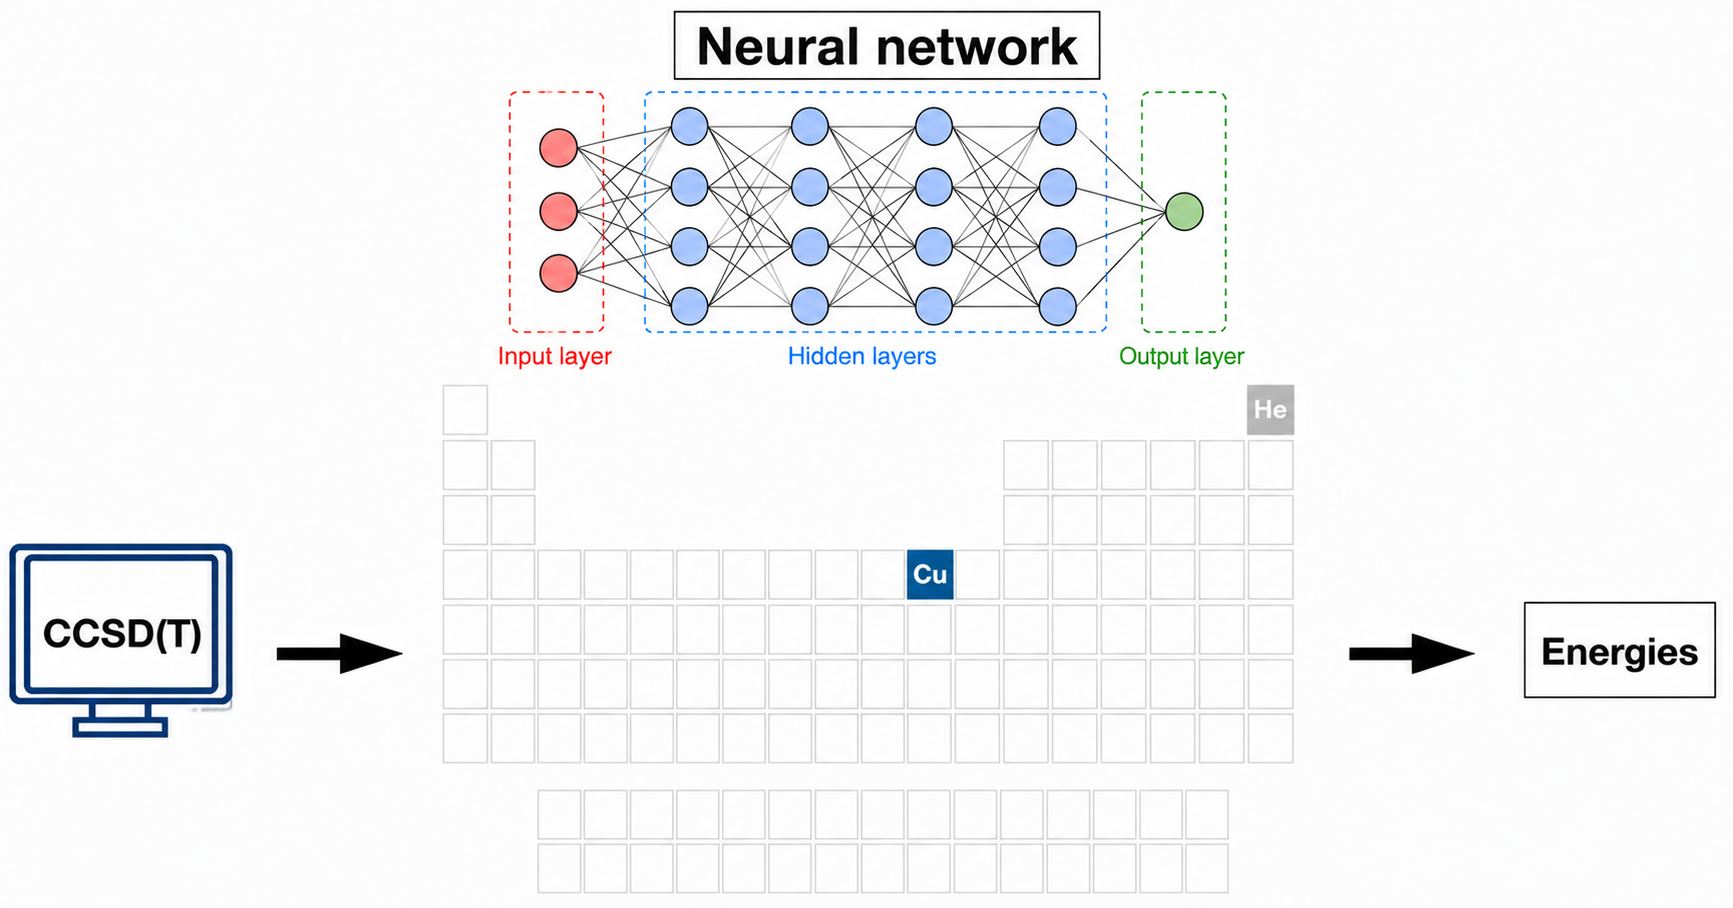

In [3]:
from IPython.display import Image, display

display(Image(filename="neural_network.png", width=1000))

# 🧒**Let's investigate whether a machine learning model, specifically a neural network ensemble, can accurately reproduce the CCSD(T) Cu–He binding energy curve and provide an estimate of the prediction uncertainty.**

## **Goal:** The idea is to be able to replace computationally expensive ab initio calculations (for more complex systems with many degree of freedoms) with accurate and efficient machine learning surrogate models that can predict energies in a fraction of a second.

> **Recommended reading**

Xiangyue Liu, **From Spectroscopic Constants of Diatomic Molecules to Quantum Computing with Ultracold Molecules**, PhD Dissertation, Freie Universität Berlin (2023).

Available at:
https://refubium.fu-berlin.de/bitstream/handle/fub188/42143/Dissertation_Xiangyue_Liu.pdf?sequence=3&isAllowed=y

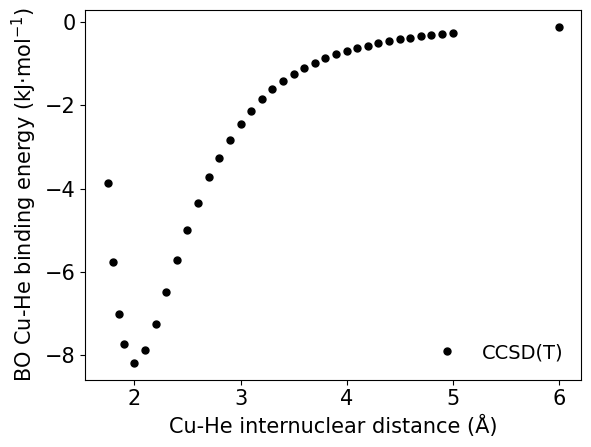

In [18]:
# FOR Cu+-He
xdata=np.array([1.75,1.8,1.85,1.9,2,2.1,2.2,2.3,2.4,2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5,3.6,3.7,
                3.8,3.9,4.0,4.1, 4.2, 4.3,4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 6.0])

ydata=np.array([-3.8563344,-5.77531235,-7.00404635,-7.7284218,-8.186309,-7.8891024,-7.24664255,-6.48209695,-5.71125015,
       -4.9895002,-4.3394264,-3.71522955,-3.2640216,-2.82950135,-2.4537923,-2.13059325,-1.85334045,-1.61652035,
       -1.41488195,-1.2434368,-1.0979841,-0.9735354,-0.866415,-0.77373485,-0.693132, -0.6222435,
     -0.5597566,-0.5046211,-0.4557868,-0.41246605,-0.37413375,-0.3397397,-0.30902135,-0.28171615,-0.25703645, -0.1092208])

#plt.plot(xdata, ydata, color='dodgerblue', markersize=5, marker='o', markerfacecolor='none', lw=2.5)
#plt.plot(xdata, ydata, linestyle='None', marker='o', markersize=5, markerfacecolor='none', markeredgecolor='dodgerblue', label='CCSD(T)')
plt.plot(xdata, ydata, linestyle='None', marker='o', markersize=5, markerfacecolor='black', markeredgecolor='black', label='CCSD(T)')


# Labeling and axes limits
plt.xlabel('Cu-He internuclear distance (Å)', fontsize=15)
plt.ylabel('BO Cu-He binding energy (kJ·mol$^{-1}$)', fontsize=15)
plt.tick_params(labelsize=15)

plt.legend(fontsize=14, frameon=False, loc='lower right')

In [19]:
# Reshape for neural network
X = xdata.reshape(-1, 1)
y = ydata.reshape(-1, 1)

# Scale input and output
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

**Q1: Why reshaping?**

▶**R1**: Because TensorFlow expects the input to have the shape

(number of samples, number of features). In this case, number of samples=36 and the number of features = 1

$$
x_{\mathrm{scaled}}=\frac{x-\mu}{\sigma}
$$

where

- $\mu$ = mean
- $\sigma$ = standard deviation

**Q2: Why scaling?**

▶**R2**: Because, the neural network usually converges much faster on normalized values. However, for this problem, it is not necessarily important to scale as the range of values is alreary quite small and the input consists of only 36 points and a single feature (internuclear distance).

**These are the equations corresponding directly to the code in the cell bellow**

| Code            | Mathematical equation                      |
| --------------- | ------------------------------------------ |
| `build_model()` | $(\hat{E}(R)=f(R;\theta_i))$                 |
| `loss='mse'`    | $(\mathcal{L}=\frac{1}{N}\sum(E-\hat{E})^2)$ |
| `epochs=1000`   | Repeated optimization of ($\theta$)          |
| `np.mean()`     | $(\bar{E}(R))$                               |
| `np.std()`      | $(\sigma(R))$                                |


$$
\mathcal{L}
=
\frac{1}{N}
\sum_{j=1}^{N}
\left(E_j-\hat{E}_j\right)^2
$$

$$
\bar{E}(R)
=
\frac{1}{M}
\sum_{i=1}^{M}
\hat{E}_i(R)
$$

$$
\sigma(R)
=
\sqrt{
\frac{1}{M}
\sum_{i=1}^{M}
\left(
\hat{E}_i(R)-\bar{E}(R)
\right)^2
}
$$

$$
\bar{E}(R)\pm2\sigma(R).
$$

**Summary**

| Code                 | Mathematical equation                                             |
| -------------------- | ----------------------------------------------------------------- |
| `model.predict(...)` | $(\hat{E}_i(R)=f(R;\theta_i)) $                                     |
| `np.mean(...)`       | $(\bar{E}(R)=\frac{1}{M}\sum_{i=1}^{M}\hat{E}_i(R))$                |
| `np.std(...)`        | $(\sigma(R)=\sqrt{\frac{1}{M}\sum_{i=1}^{M}(\hat{E}_i-\bar{E})^2})$ |
| `fill_between(...)`  | $(\bar{E}(R)\pm2\sigma(R))$                                         |


where

- $M=30$,
- $E_j$ is the CCSD(T) energy,
- $\hat{E}_j$ is the predicted energy,
- $N$ is the number of training points.

In [27]:
# Train many neural networks
n_models = 30
models = []

for i in range(n_models):
    print(f"Training model {i+1}/{n_models}")

    tf.keras.utils.set_random_seed(i)

    model = build_model()

    model.fit(
        X_scaled,
        y_scaled,
        epochs=1000,
        verbose=0
    )

    models.append(model)

Training model 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model 2/30
Training model 3/30
Training model 4/30
Training model 5/30
Training model 6/30
Training model 7/30
Training model 8/30
Training model 9/30
Training model 10/30
Training model 11/30
Training model 12/30
Training model 13/30
Training model 14/30
Training model 15/30
Training model 16/30
Training model 17/30
Training model 18/30
Training model 19/30
Training model 20/30
Training model 21/30
Training model 22/30
Training model 23/30
Training model 24/30
Training model 25/30
Training model 26/30
Training model 27/30
Training model 28/30
Training model 29/30
Training model 30/30


Above, I train **30 independent neural networks**. I then give each neural network a different random starting point (different initial weights) so that each network learns slightly differently. Finally, I train each neural network for **1000 epochs (iterations)** so that it learns the relationship between the Cu–He internuclear distance and the CCSD(T) binding energy.

**Summary:** The code trains **30 slightly different neural networks** on the same dataset. It then computes the average of their predictions as the final prediction and uses the variation among their predictions to estimate the prediction uncertainty.

**Q1: Why train 30 independent neural networks?**

▶**R1**:Thirty is simply a good compromise between prediction accuracy and computational cost. Remember, one or only a few neural networks are not sufficient because they provide only one or a few predictions, making it impossible to reliably estimate uncertainty using an ensemble.

**Q2: Why choose 1000 epochs?**

▶**R2:**Because 1000 epochs give each neural network sufficient time to converge on such a small dataset. Remember, as the number of epochs increases, the network progressively improves its predictions by learning the relationship between the input distances and the corresponding binding energies.


In [28]:
# Prediction grid
x_grid = np.linspace(1.75, 8.0, 400).reshape(-1, 1)
x_grid_scaled = x_scaler.transform(x_grid)

# Predict with all models
all_predictions = []

for model in models:
    pred_scaled = model.predict(x_grid_scaled, verbose=0)
    pred = y_scaler.inverse_transform(pred_scaled)
    all_predictions.append(pred.ravel())

all_predictions = np.array(all_predictions)

# Mean and uncertainty
mean_prediction = np.mean(all_predictions, axis=0)
std_prediction = np.std(all_predictions, axis=0)

In the cell above, all predictions from the 30 neural networks are stored together. Finally, for each distance on the prediction grid:

▶ The mean of the 30 predictions is computed. This is the final neural network prediction.

▶ The standard deviation of the 30 predictions is computed. This measures how much the neural networks disagree and is used to estimate the prediction uncertainty (shaded region).

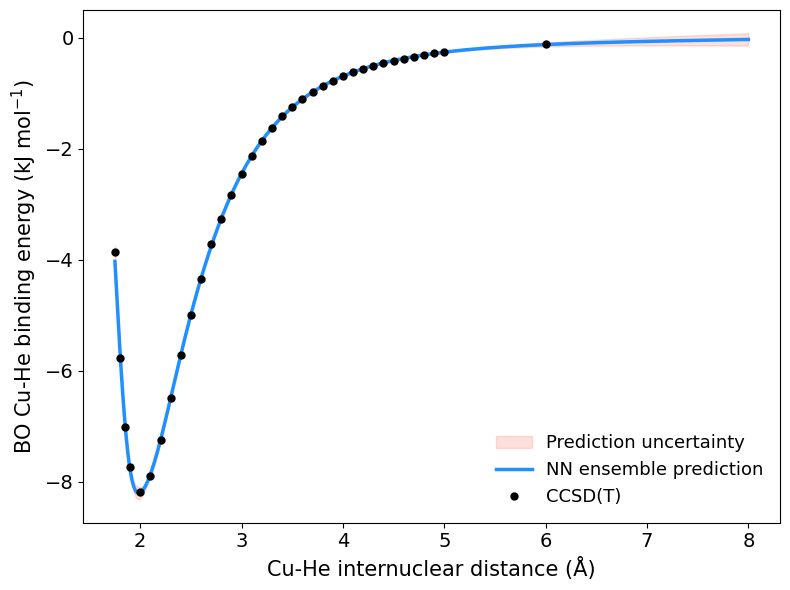

In [29]:
# Plot
plt.figure(figsize=(8, 6))

# Uncertainty region
plt.fill_between(
    x_grid.ravel(),
    mean_prediction - 2*std_prediction,
    mean_prediction + 2*std_prediction,
    alpha=0.25,
    label='Prediction uncertainty',
     color='salmon'
)

# Mean NN prediction
plt.plot(
    x_grid,
    mean_prediction,
    color='dodgerblue',
    lw=2.5,
    label='NN ensemble prediction'
)

# CCSD(T) points
plt.plot(
    xdata,
    ydata,
    linestyle='None',
    marker='o',
    markersize=5,
    color='black',
    label='CCSD(T)'
)

plt.xlabel('Cu-He internuclear distance (Å)', fontsize=15)
plt.ylabel('BO Cu-He binding energy (kJ mol$^{-1}$)', fontsize=15)
plt.tick_params(labelsize=14)
plt.legend(fontsize=13, frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

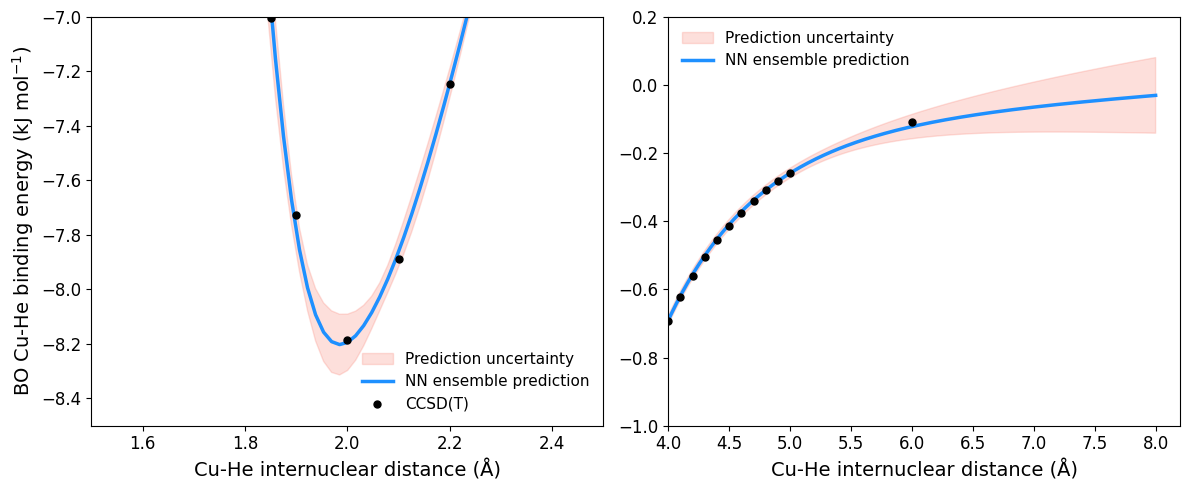

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# =====================================================
# LEFT PANEL (Zoom around the minimum)
# =====================================================
ax1.fill_between(
    x_grid.ravel(),
    mean_prediction - 2*std_prediction,
    mean_prediction + 2*std_prediction,
    color='salmon',
    alpha=0.25,
    label='Prediction uncertainty'
)

ax1.plot(
    x_grid,
    mean_prediction,
    color='dodgerblue',
    lw=2.5,
    label='NN ensemble prediction'
)

ax1.plot(
    xdata,
    ydata,
    linestyle='None',
    marker='o',
    markersize=5,
    color='black',
    label='CCSD(T)'
)

ax1.set_xlim(1.5, 2.5)
ax1.set_ylim(-8.5, -7.0)

ax1.set_xlabel('Cu-He internuclear distance (Å)', fontsize=14)
ax1.set_ylabel('BO Cu-He binding energy (kJ mol$^{-1}$)', fontsize=14)
ax1.tick_params(labelsize=12)
ax1.legend(frameon=False, fontsize=11)

# =====================================================
# RIGHT PANEL (Zoom from 5.0 Å to 8 Å)
# =====================================================
ax2.fill_between(
    x_grid.ravel(),
    mean_prediction - 2*std_prediction,
    mean_prediction + 2*std_prediction,
    color='salmon',
    alpha=0.25,
    label='Prediction uncertainty'
)

ax2.plot(
    x_grid,
    mean_prediction,
    color='dodgerblue',
    lw=2.5,
    label='NN ensemble prediction'
)

ax2.plot(
    xdata,
    ydata,
    linestyle='None',
    marker='o',
    markersize=5,
    color='black'
)

ax2.set_xlim(4.0, 8.2)
ax2.set_ylim(-1, 0.2)

ax2.set_xlabel('Cu-He internuclear distance (Å)', fontsize=14)
ax2.tick_params(labelsize=12)
ax2.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

The figure obtained shows: One-dimensional Cu–He binding energy curve obtained using an ensemble of neural networks. The black dots represent the reference CCSD(T) binding energies, while the blue curve corresponds to the mean prediction of the neural network ensemble. The shaded salmon region indicates the prediction uncertainty, estimated from the standard deviation of the ensemble predictions. The left panel shows a magnified view of the potential minimum, whereas the right panel highlights the long-range asymptotic region, where the uncertainty gradually increases because fewer reference data are available and the model performs extrapolation.

# **Result:**

From the figure, the prediction uncertainty is mainly visible in the following regions:

1. **Near the potential minimum**, around $R \approx 2.0\$ Ångström, although it remains relatively small.

2. **In the long-range interaction region**, particularly for $R > 6.0\$ Ångström, where the uncertainty band becomes progressively wider.

# **Interpretation**
Since the potential minimum is the most physically important region, a larger prediction uncertainty in this region suggests that additional training data could be generated around the minimum to improve the model's accuracy and confidence.


By contrast, the Morse potential assumes beforehand that the energy has the form:
$$
E(R)=D_e\left(1-e^{-a(R-R_e)}\right)^2-D_e,
$$
which works very well for many diatomic systems

# **Conclusion**
Was machine learning really necessary for this example Cu–He system?

Strictly speaking, no.For a two-body system such as Cu–He, a Morse potential,
would already reproduce the curve extremely well.

Therefore, machine learning is not necessary from a computational standpoint here. However, this exercise (diatomic Cu–He interaction) serves as a proof of concept. Therefore, once the workflow is validated, it can be extended to much more challenging systems where analytical models such as the Morse potential are no longer applicable.

# **Machine Learning Workflow for Potential Energy Prediction**

In [56]:
from google.colab import files
uploaded = files.upload()

Saving summary.png to summary.png


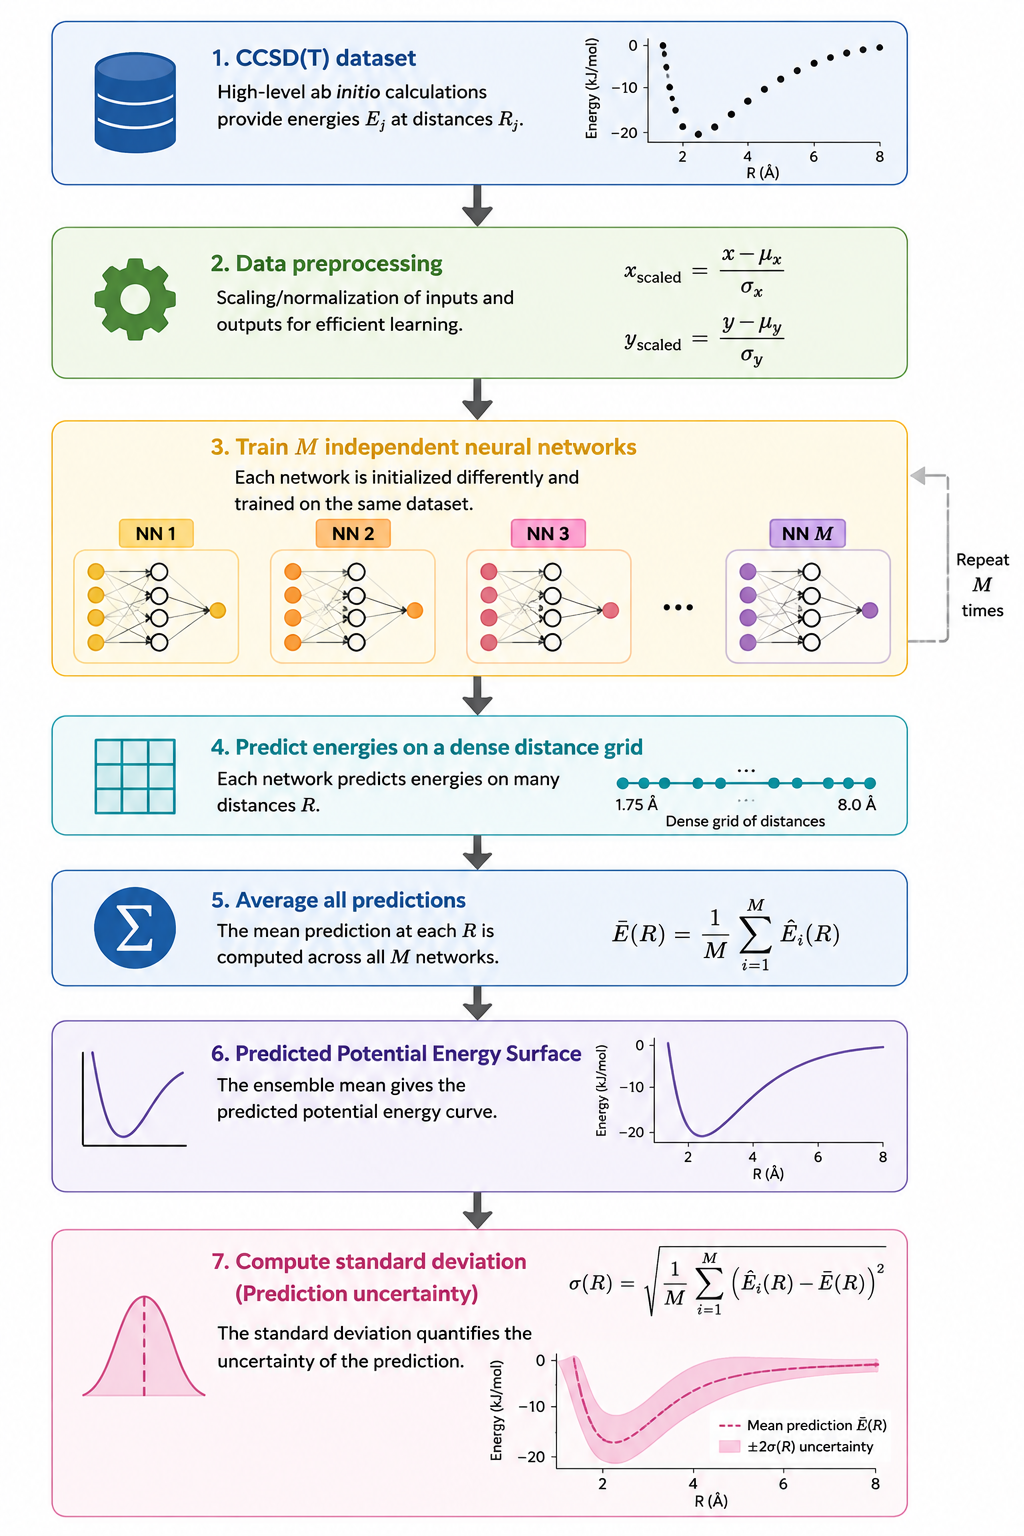

In [58]:
from IPython.display import Image, display

display(Image(filename="summary.png", width=1000))